In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

In [57]:
def calculate_return(signal):
    # signal = [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance = 10000000
    init_balance = balance

    list_rtn = []

    for item in signal:
        score = float(item[1])
        price = float(item[2])

        # if hold == 0:
        #     if score > 0:
        #         hold += int(balance/price)
        #         balance = 0
        # elif hold > 0:
        #     if score < 0:
        #         balance += price*hold
        #         hold = 0

        if hold == 0:
            if score == 2:
                hold += int(balance/price)
                balance = 0
            elif score == 1:
                hold += int((balance/2)/price)
                balance = int(balance/2)
        elif hold > 0:
            if score < 0:
                balance += price*hold
                hold = 0
            elif score == 2:
                hold += int(balance/price)
                balance = 0
        # print(f"score: {score}, price: {price}, hold: {hold}, balance: {balance}, total: {balance + hold*price}")

        list_rtn.append((balance + hold*price)/init_balance)
    
    balance += hold*price
    last_price = float(signal[len(signal) - 1][2])
    r = balance/init_balance

    # plt.title({stock_id})
    # plt.plot(list_rtn, label=f'strategy', color='red')
    # plt.plot(list_bnh, label='buy and hold', color='blue')
    # plt.legend()
    # plt.show()

    return round(r, 5)

157 X1.0352590000000002
158 X1.0356699999999999
159 X1.0666299999999997
160 X1.08936375
161 X1.076111
162 X1.0741654999999999
163 X1.0738251428571428
164 X1.0669316249999998
165 X1.0727858888888888
166 X1.0782106999999996
167 X1.0713088181818178
168 X1.0704579999999997
169 X1.0691781538461536
170 X1.0670220714285712
171 X1.0688930666666663
172 X1.0687582499999992
173 X1.073940647058823
174 X1.074194666666666
175 X1.0737990526315782
176 X1.0749723999999994
177 X1.0746933333333326
178 X1.073548045454545
179 X1.072694130434782
180 X1.0698752499999993
181 X1.0693806399999994
182 X1.0683263846153839
183 X1.0694489629629622
184 X1.0694930714285706
185 X1.0659180689655159
186 X1.0682416666666654
187 X1.0697132258064503
188 X1.0694621562499989
189 X1.0727153333333321
190 X1.0730282941176463
191 X1.0748253428571422
192 X1.0746243333333327
193 X1.0738783783783779
194 X1.0751250526315785
195 X1.0747778717948715
196 X1.0740279249999998
197 X1.0746448780487805
198 X1.0750865238095237
199 X1.0739863

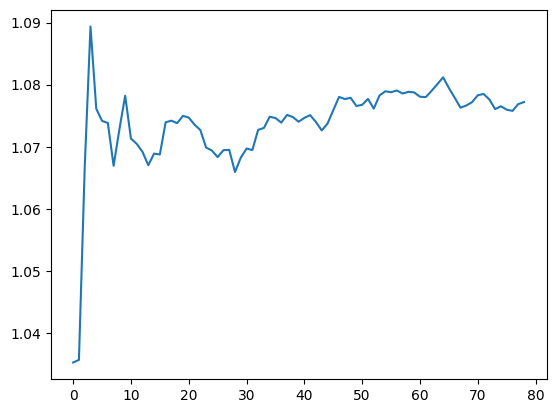

In [58]:
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022
import matplotlib.pyplot as plt

import ast

rtns = []
bnhs = []
eval_list = []
list_2 = []

for i in range(157, 236):
    with open("eval_gemini/output"+str(i), "r") as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    for list in eval_list:

        rtn = calculate_return(list)
        # print(f'報酬率:{rtn}，總額投入報酬率:{bnh} ',end="==>")  
        # print("勝利" if rtn > bnh else "失敗")
        rtns.append(rtn)



    # print("_"*50)
    # print(f'平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{1.186132}')
    print(str(i) + "策略勝利" if sum(rtns) / len(rtns) > 1.186132 else str(i) + " X" + str(sum(rtns) / len(rtns)))
    list_2.append(sum(rtns) / len(rtns))
    # raw_data.append(signal_2_np.tolist())
plt.plot(list_2)
print(list_2)